# State space formalism - pedagogical approach

**Goal:** Introduction to state space formalism by gradually moving from intuition to abstraction.

**Method:**
1. Analogy to a board game
2. Concrete example (2×2 grid)
3. Symbolic generalization
4. Formal definitions
5. Interactive game

**Concepts:** $X$, $U(x)$, $f(x,u)$, $l(x,u)$, $l_F(x)$, $L$, $\pi^*$

## 1. Analogy to a board game

Imagine you are playing a board game:

| In a board game | In robotics |
|:---|:---|
| Pawn | Robot |
| Square the pawn is on | State $x$ |
| All squares on the board | State space $X$ |
| Allowed moves from a square | Action space $U(x)$ |
| Rule: "from square X you go to Y" | Transition function $f(x,u)$ |
| Points lost per move | Stage cost $l(x,u)$ |
| Bonus for reaching the finish | Terminal cost $l_F(x)$ |
| Total points in the game | Cost functional $L$ |
| Best sequence of moves | Optimal plan $\pi^*$ |

In [1]:
from typing import List, Optional
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output

# Optional: suppress warnings
import warnings
warnings.filterwarnings('ignore')

## 2. Concrete example - robot on a 2×2 grid

The robot has to go from **A** to **D**, avoiding obstacle **C**.

In [2]:
# ============================================================================
# WORLD DEFINITION (concrete example)
# ============================================================================

class State:
    """Robot state on a grid"""
    def __init__(self, x: int, y: int, name: str):
        self.x = x
        self.y = y
        self.name = name
    
    def __repr__(self):
        return self.name
    
    def __eq__(self, other):
        if not isinstance(other, State):
            return False
        return self.x == other.x and self.y == other.y
    
    def __hash__(self):
        return hash((self.x, self.y))

# Create states
A = State(0, 0, 'A')  # start
B = State(0, 1, 'B')
# C = State(1, 0, 'C')  # skip - it's an obstacle
D = State(1, 1, 'D')  # goal

# State space X
X = [A, B, D]
start = A
goal = D
obstacle = (1, 0)  # obstacle coordinates

print("State space X =", [s.name for s in X])
print(f"Start: {start.name}, Goal: {goal.name}, Obstacle: {obstacle}")

State space X = ['A', 'B', 'D']
Start: A, Goal: D, Obstacle: (1, 0)


### Step 1: Manual cost calculation

We do this **manually**, without any definitions.

Path: **A → B → D**

Cost: each move costs **1**, reaching the goal costs **0**.

In [3]:
# Manual calculation (concrete values)
print("=" * 50)
print("STEP 1: MANUAL CALCULATION")
print("=" * 50)

print("\nPath: A → B → D\n")
print("  Move 1: A → B  (cost = 1)")
print("  Move 2: B → D  (cost = 1)")
print("  Reaching goal: (terminal cost = 0)")
print("\n  TOTAL COST = 1 + 1 + 0 = 2\n")

print("💡 This is a concrete result for this specific case.")

STEP 1: MANUAL CALCULATION

Path: A → B → D

  Move 1: A → B  (cost = 1)
  Move 2: B → D  (cost = 1)
  Reaching goal: (terminal cost = 0)

  TOTAL COST = 1 + 1 + 0 = 2

💡 This is a concrete result for this specific case.


### Step 2: Symbolic notation (generalization)

Now we write the same thing, but using **symbols**.

Plan $\pi = (u_1, u_2)$ where:
- $u_1 = \text{'right'}$ (A → B)
- $u_2 = \text{'down'}$ (B → D)

Total cost:

$$L(\pi) = l(A, u_1) + l(B, u_2) + l_F(D)$$

$$L(\pi) = 1 + 1 + 0 = 2$$

This is a **generalization** - we use symbols instead of concrete values.

In [4]:
print("=" * 50)
print("STEP 2: SYMBOLIC NOTATION")
print("=" * 50)

print("\nPlan π = (u₁, u₂) where:")
print("  u₁ = 'right'   (A → B)")
print("  u₂ = 'down'    (B → D)")

print("\nTotal cost:")
print("  L(π) = l(A, u₁) + l(B, u₂) + l_F(D)")
print("  L(π) = 1 + 1 + 0 = 2")

print("\n💡 We use symbols (l, L, π) instead of concrete numbers.")

STEP 2: SYMBOLIC NOTATION

Plan π = (u₁, u₂) where:
  u₁ = 'right'   (A → B)
  u₂ = 'down'    (B → D)

Total cost:
  L(π) = l(A, u₁) + l(B, u₂) + l_F(D)
  L(π) = 1 + 1 + 0 = 2

💡 We use symbols (l, L, π) instead of concrete numbers.


### Step 3: Formal definition (abstraction)

Now we provide the **general formula** that works for ANY robot.

For plan $\pi_K = (u_1, u_2, \ldots, u_K)$:

$$L(\pi_K) = \sum_{k=1}^{K} l(x_k, u_k) + l_F(x_{K+1})$$

where:
- $l(x_k, u_k)$ = stage cost (for each move)
- $l_F(x_{K+1})$ = terminal cost (for reaching the goal)

This formula can be applied to **any** robot, **any** grid, and **any** costs.

In [5]:
print("=" * 50)
print("STEP 3: FORMAL DEFINITION (abstraction)")
print("=" * 50)

print("\nFor any plan π_K = (u₁, u₂, ..., u_K):\n")
print("  L(π_K) = Σ l(x_k, u_k) + l_F(x_{K+1})")
print("           k=1..K\n")
print("where:")
print("  l(x_k, u_k) = stage cost (for each move)")
print("  l_F(x_{K+1}) = terminal cost (for reaching the goal)")

print("\n💡 This formula works for ANY robot!")
print("   - Any number of states")
print("   - Any costs")
print("   - Any number of steps")

STEP 3: FORMAL DEFINITION (abstraction)

For any plan π_K = (u₁, u₂, ..., u_K):

  L(π_K) = Σ l(x_k, u_k) + l_F(x_{K+1})
           k=1..K

where:
  l(x_k, u_k) = stage cost (for each move)
  l_F(x_{K+1}) = terminal cost (for reaching the goal)

💡 This formula works for ANY robot!
   - Any number of states
   - Any costs
   - Any number of steps


In [6]:
# ============================================================================
# FORMALISM IMPLEMENTATION
# ============================================================================

def get_actions(state: State) -> List[str]:
    """
    Action space U(x)
    Returns allowed actions for a given state.
    """
    actions = []
    
    candidates = [
        ('right', state.x, state.y + 1),
        ('left', state.x, state.y - 1),
        ('down', state.x + 1, state.y),
        ('up', state.x - 1, state.y)
    ]
    
    for action_name, new_x, new_y in candidates:
        if (new_x, new_y) != obstacle and 0 <= new_x < 2 and 0 <= new_y < 2:
            actions.append(action_name)
    
    return actions

def transition(state: State, action: str) -> Optional[State]:
    """
    Transition function f(x,u)
    Determines the new state after executing an action.
    """
    x, y = state.x, state.y
    
    if action == 'right':
        new_x, new_y = x, y + 1
    elif action == 'left':
        new_x, new_y = x, y - 1
    elif action == 'down':
        new_x, new_y = x + 1, y
    elif action == 'up':
        new_x, new_y = x - 1, y
    else:
        return None
    
    for s in X:
        if s.x == new_x and s.y == new_y:
            return s
    return None

def stage_cost(state: State, action: str) -> float:
    """
    Stage cost l(x,u)
    We pay 1 for each move.
    """
    return 1.0

def terminal_cost(state: State) -> float:
    """
    Terminal cost l_F(x)
    0 if goal is reached, otherwise a large penalty.
    """
    if state == goal:
        return 0.0
    return 100.0

def plan_cost(path: List[State]) -> float:
    """
    Cost functional L
    Calculates total cost for a given path.
    """
    total = 0.0
    
    for i in range(len(path) - 1):
        current = path[i]
        next_state = path[i + 1]
        
        # Find action that leads to next_state
        for action in get_actions(current):
            if transition(current, action) == next_state:
                total += stage_cost(current, action)
                break
    
    total += terminal_cost(path[-1])
    return total

In [7]:
# Optimal path
path = [A, B, D]

print("=" * 60)
print("COMPARISON OF THE THREE APPROACHES")
print("=" * 60)

print("\n" + "┌──────────────┬──────────────────────┬──────────────────────┐")
print("│ Step         │ What we do           │ Result               │")
print("├──────────────┼──────────────────────┼──────────────────────┤")
print("│ 1. Concrete  │ Manual calculation   │ 1 + 1 = 2            │")
print("│ 2. Symbolic  │ Write with symbols   │ l(A)+l(B)+l_F(D)=2  │")
print("│ 3. Abstract  │ Use formula          │ Σ l + l_F = 2        │")
print("└──────────────┴──────────────────────┴──────────────────────┘")

# Cost calculation using function
cost = plan_cost(path)
print(f"\n✅ All three approaches yield the same result: L = {cost}")

COMPARISON OF THE THREE APPROACHES

┌──────────────┬──────────────────────┬──────────────────────┐
│ Step         │ What we do           │ Result               │
├──────────────┼──────────────────────┼──────────────────────┤
│ 1. Concrete  │ Manual calculation   │ 1 + 1 = 2            │
│ 2. Symbolic  │ Write with symbols   │ l(A)+l(B)+l_F(D)=2  │
│ 3. Abstract  │ Use formula          │ Σ l + l_F = 2        │
└──────────────┴──────────────────────┴──────────────────────┘

✅ All three approaches yield the same result: L = 2.0


## 3. Visualization

Visualization of the grid and the optimal path.

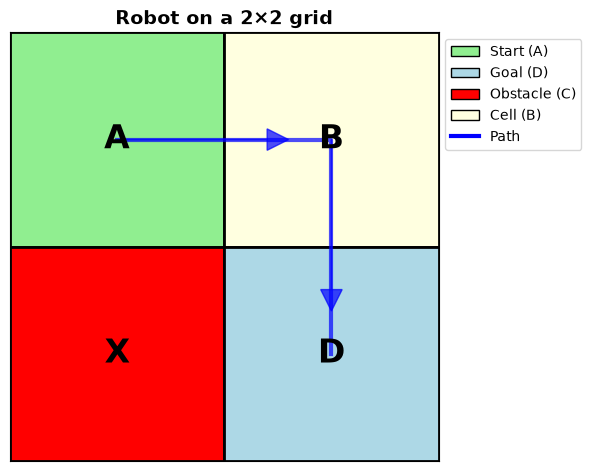

In [8]:
def visualize_grid(path: List[State] = None):
    """
    Visualization of a 2×2 grid with a path.
    """
    fig, ax = plt.subplots(figsize=(6, 6))
    
    # 2×2 grid
    grid_data = [['A', 'B'], ['X', 'D']]
    
    for i in range(2):
        for j in range(2):
            cell = grid_data[i][j]
            
            if cell == 'X':
                color = 'red'
            elif cell == 'A':
                color = 'lightgreen'
            elif cell == 'D':
                color = 'lightblue'
            else:
                color = 'lightyellow'
            
            ax.add_patch(plt.Rectangle((j, 1 - i), 1, 1,
                                      facecolor=color, edgecolor='black', linewidth=2))
            
            ax.text(j + 0.5, 1 - i + 0.5, cell,
                   ha='center', va='center', fontsize=24, fontweight='bold')
    
    # Path
    if path:
        # Mapping names to coordinates
        coord_map = {'A': (0.5, 1.5), 'B': (1.5, 1.5), 'D': (1.5, 0.5)}
        points = [coord_map[s.name] for s in path if s.name in coord_map]
        
        if len(points) > 1:
            xs, ys = zip(*points)
            ax.plot(xs, ys, 'b-', linewidth=3, alpha=0.7, label='Path')
            
            # Arrows
            for i in range(len(xs) - 1):
                dx = xs[i+1] - xs[i]
                dy = ys[i+1] - ys[i]
                ax.arrow(xs[i], ys[i], dx*0.7, dy*0.7,
                        head_width=0.1, head_length=0.1,
                        fc='blue', ec='blue', alpha=0.7)
    
    # Settings
    ax.set_xlim(0, 2)
    ax.set_ylim(0, 2)
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title('Robot on a 2×2 grid', fontsize=14, fontweight='bold')
    
    # Legend
    legend_elements = [
        plt.Rectangle((0,0), 1, 1, facecolor='lightgreen', edgecolor='black', label='Start (A)'),
        plt.Rectangle((0,0), 1, 1, facecolor='lightblue', edgecolor='black', label='Goal (D)'),
        plt.Rectangle((0,0), 1, 1, facecolor='red', edgecolor='black', label='Obstacle (C)'),
        plt.Rectangle((0,0), 1, 1, facecolor='lightyellow', edgecolor='black', label='Cell (B)'),
        plt.Line2D([0], [0], color='blue', linewidth=3, label='Path')
    ]
    ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1, 1))
    
    plt.tight_layout()
    plt.show()

# Visualization
visualize_grid(path)


## 4. Formalism summary

Summary of all formalism elements.

In [9]:
print("=" * 70)
print("STATE SPACE FORMALISM SUMMARY")
print("=" * 70)

print("""
┌──────────────────────────────┬────────────────────────────────────┬──────────────────────┐
│ Formalism element            │ Definition                         │ In example           │
├──────────────────────────────┼────────────────────────────────────┼──────────────────────┤
│ X (state space)              │ Set of all possible                │ {A, B, D}            │
│                              │ system configurations              │                      │
├──────────────────────────────┼────────────────────────────────────┼──────────────────────┤
│ U(x) (action space)          │ Set of allowed controls            │ U(A) = {right}       │
│                              │ in state x                         │ U(B) = {down}        │
│                              │                                    │ U(D) = {}            │
├──────────────────────────────┼────────────────────────────────────┼──────────────────────┤
│ f(x,u) (transition function) │ Deterministic mapping              │ f(A, right) = B      │
│                              │ x' = f(x, u)                       │ f(B, down) = D       │
├──────────────────────────────┼────────────────────────────────────┼──────────────────────┤
│ l(x,u) (stage cost)          │ Cost for taking one step           │ 1 (per move)         │
├──────────────────────────────┼────────────────────────────────────┼──────────────────────┤
│ l_F(x) (terminal cost)       │ Cost for being in a                │ 0 (at goal)          │
│                              │ terminal state                     │ 100 (not at goal)    │
├──────────────────────────────┼────────────────────────────────────┼──────────────────────┤
│ L (cost functional)          │ L = Σ l(x_k, u_k) + l_F(x_{K+1})   │ 1 + 1 + 0 = 2        │
├──────────────────────────────┼────────────────────────────────────┼──────────────────────┤
│ π* (optimal plan)            │ π* = argmin L(π)                   │ A → B → D            │
└──────────────────────────────┴────────────────────────────────────┴──────────────────────┘
""")


STATE SPACE FORMALISM SUMMARY

┌──────────────────────────────┬────────────────────────────────────┬──────────────────────┐
│ Formalism element            │ Definition                         │ In example           │
├──────────────────────────────┼────────────────────────────────────┼──────────────────────┤
│ X (state space)              │ Set of all possible                │ {A, B, D}            │
│                              │ system configurations              │                      │
├──────────────────────────────┼────────────────────────────────────┼──────────────────────┤
│ U(x) (action space)          │ Set of allowed controls            │ U(A) = {right}       │
│                              │ in state x                         │ U(B) = {down}        │
│                              │                                    │ U(D) = {}            │
├──────────────────────────────┼────────────────────────────────────┼──────────────────────┤
│ f(x,u) (transition function) │ Determ